# Proyek Klasifikasi Gambar: [Colors Dataset]
- **Nama:** [Refanda Surya Saputra]
- **Email:** [refandasuryasaputra@gmail.com]
- **ID Dicoding:** [refanda_surya]

## Import Semua Packages/Library yang Digunakan

In [56]:
# Melakukan import library
import os
import zipfile
import random
from importlib.metadata import distribution
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize, rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, \
    Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import gdown

# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.15.0


## Data Preparation

### Data Loading

**Data Preparation**

In [11]:
# ID File
file_id = "1-1gVGMta4WZxB78hN6mXEIrOsa9VR2SI"
url = f"https://drive.google.com/uc?id={file_id}"

# Unduh dalam bentuk zip
gdown.download(url, 'colors-dataset.zip', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1-1gVGMta4WZxB78hN6mXEIrOsa9VR2SI
From (redirected): https://drive.google.com/uc?id=1-1gVGMta4WZxB78hN6mXEIrOsa9VR2SI&confirm=t&uuid=f1153d4b-24a0-4709-bae3-7b921ad41638
To: /home/refanzzzz/PycharmProjects/colors-image-classification/colors-dataset.zip
100%|██████████| 45.3M/45.3M [00:08<00:00, 5.07MB/s]


'colors-dataset.zip'

In [12]:
# Unzip berkas yang telah diunduh dari google drive
with zipfile.ZipFile('colors-dataset.zip', 'r') as zip_file:
    zip_file.extractall()

**Dataset Checking**

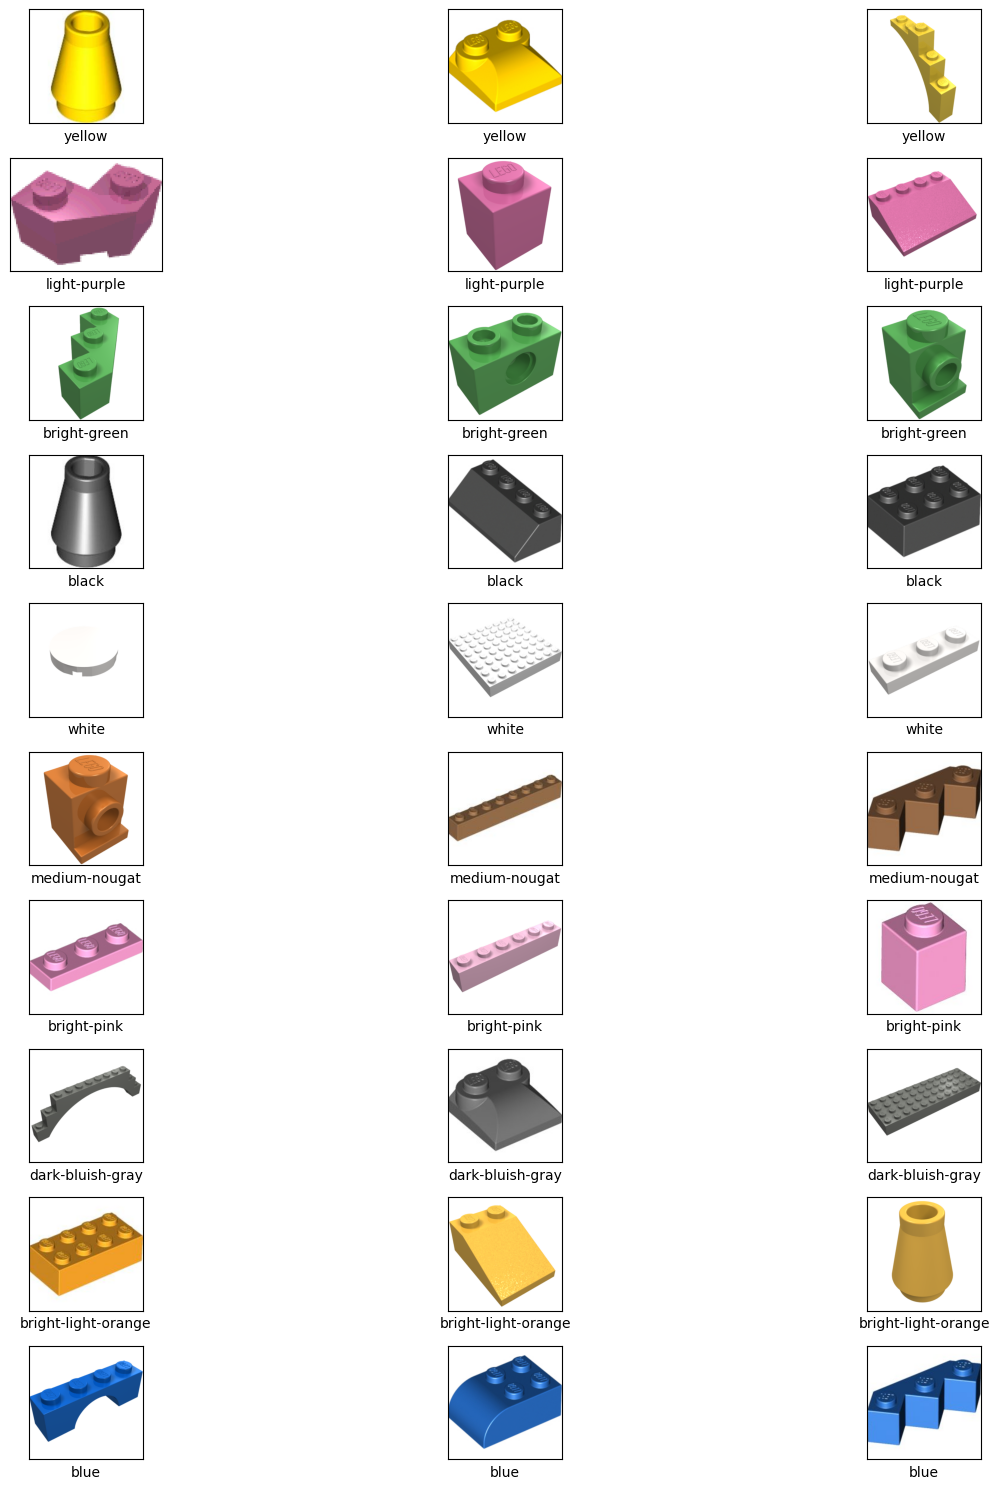

In [53]:
# Membuat dict yang menyimpan gambar untuk setiap kelas dalam data
color_image = {}

# Menentukan path sumber dataset
path = "colors-dataset/"
for i in os.listdir(path):
    color_image[i] = os.listdir(path + i)

# Menampilkan secara acak 3 gambar di bawah hanya 10 kelas saja
fig, ax = plt.subplots(10, 3, figsize=[15, 15])

for i, class_name in enumerate(os.listdir(path)):
    images = np.random.choice(color_image[class_name], 3, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path, class_name, image_name)
        img = Image.open(img_path)
        ax[i, j].imshow(img)
        ax[i, j].set(xlabel=class_name, xticks=[], yticks=[])

    if i == 9: break

fig.tight_layout()

In [61]:
# Membuat fungsi untuk melihat jumlah citra dan ukuran resolusi
def print_images_resoulution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)

        print(f"{subdir}: {num_images}")
        total_images += num_images

        for image_file in image_files:
            img_path = os.path.join(subdir_path, image_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")

        print("------------------")

    print(f"\nTotal: {total_images}")

print_images_resoulution("colors-dataset")

yellow: 41
- (192, 192)
- (500, 500)
------------------
light-purple: 4
- (100, 75)
- (192, 192)
- (500, 500)
------------------
bright-green: 26
- (100, 75)
- (192, 192)
- (500, 500)
------------------
black: 42
- (100, 75)
- (192, 192)
- (500, 500)
------------------
white: 37
- (100, 75)
- (192, 192)
- (500, 500)
------------------
medium-nougat: 25
- (100, 75)
- (192, 192)
- (500, 500)
------------------
bright-pink: 21
- (100, 75)
- (192, 192)
- (500, 500)
------------------
dark-bluish-gray: 37
- (100, 75)
- (192, 192)
- (500, 500)
------------------
bright-light-orange: 23
- (100, 75)
- (192, 192)
- (500, 500)
------------------
blue: 41
- (100, 75)
- (192, 192)
- (500, 500)
------------------
light-green: 9
- (100, 75)
- (192, 192)
- (500, 500)
------------------
light-nougat: 20
- (100, 75)
- (192, 192)
- (500, 500)
------------------
light-lime: 5
- (100, 75)
- (192, 192)
- (500, 500)
------------------
orange: 31
- (100, 75)
- (192, 192)
- (500, 500)
------------------
light

**Distribution Plot**

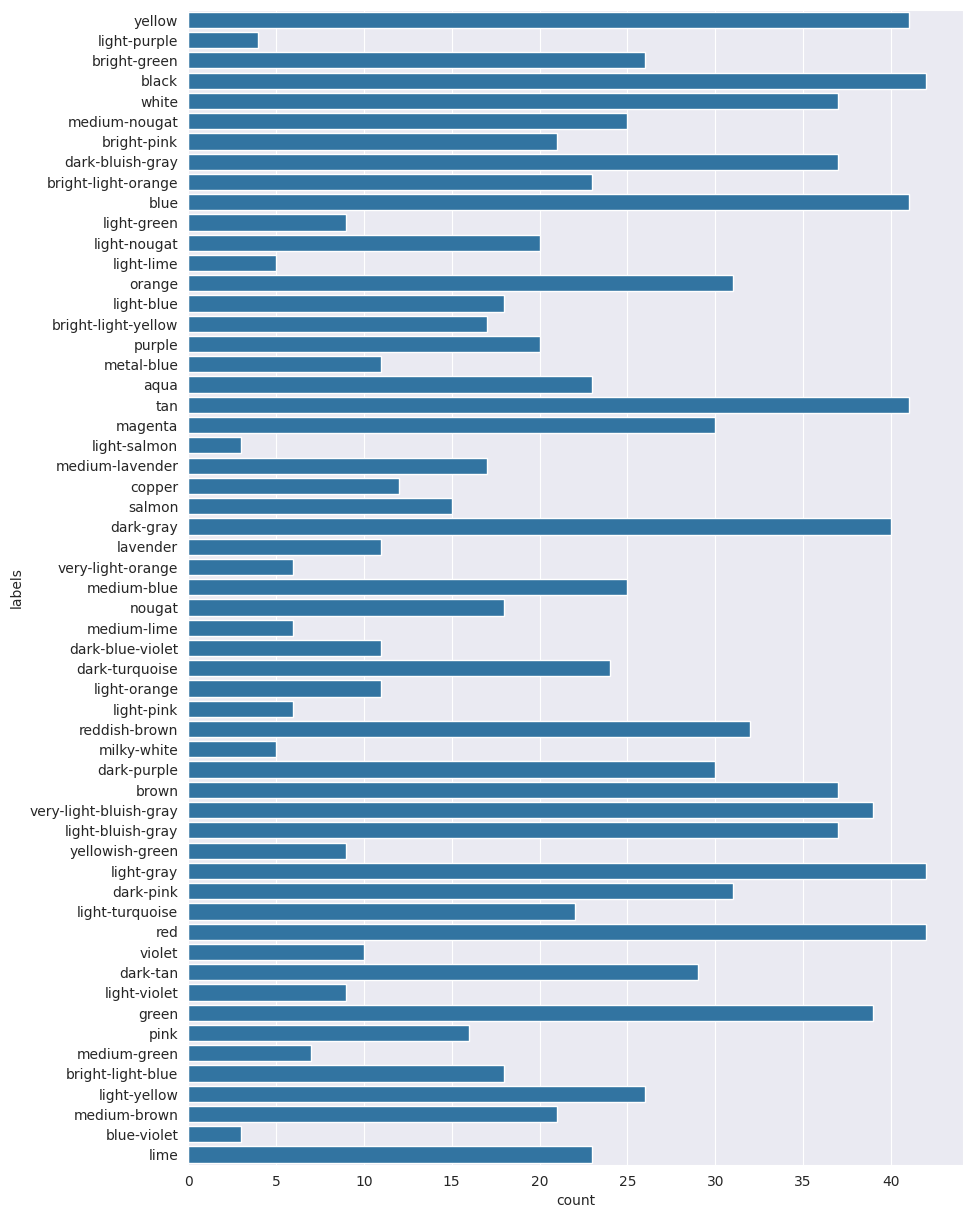

In [60]:
# Mendefinisikan path sumber
color_path = "colors-dataset/"

# Membuat daftar yang menyimpan data untuk setiap nama file, path filem dan label dalam data
file_name = []
labels = []
full_path = []

# Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
for path, subdirs, files in os.walk(color_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({
    'path': full_path,
    'file_name': file_name,
    'labels': labels
})

# Plot distribusi gambar setiap kelas
label = distribution_train['labels']
plt.figure(figsize=(10, 15))
sns.set_style("darkgrid")
plot_data = sns.countplot(label)

### Data Preprocessing

#### Augmentation Data

In [ ]:
# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 224))

#### Split Dataset

## Modelling

## Evaluasi dan Visualisasi

## Konversi Model

## Inference (Optional)